In [1]:
# Download the dataset file to local storage (from publicly shared drive file)
#
# Original source: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques
!gdown 1Yhw8tBCmjYrDZ5Rm1xPrP2y5bmBmxoEP

Downloading...
From: https://drive.google.com/uc?id=1Yhw8tBCmjYrDZ5Rm1xPrP2y5bmBmxoEP
To: /content/housing.csv
100% 461k/461k [00:00<00:00, 49.2MB/s]


In [2]:
# Import required libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load the dataset file into memory
DATASET_PATH = "./housing.csv"
df = pd.read_csv(DATASET_PATH)
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [4]:
# Display all the number of nan values in each column and type
column_stats_raw = []
for column_name in df.columns:
  column_stats_raw.append((column_name, df[column_name].dtype, df[column_name].isna().sum()))
column_stats_df = pd.DataFrame(column_stats_raw, columns=['Column name', 'Type', 'Number of null values'])

print(column_stats_df.to_string())

      Column name     Type  Number of null values
0              Id    int64                      0
1      MSSubClass    int64                      0
2        MSZoning   object                      0
3     LotFrontage  float64                    259
4         LotArea    int64                      0
5          Street   object                      0
6           Alley   object                   1369
7        LotShape   object                      0
8     LandContour   object                      0
9       Utilities   object                      0
10      LotConfig   object                      0
11      LandSlope   object                      0
12   Neighborhood   object                      0
13     Condition1   object                      0
14     Condition2   object                      0
15       BldgType   object                      0
16     HouseStyle   object                      0
17    OverallQual    int64                      0
18    OverallCond    int64                      0


<Axes: >

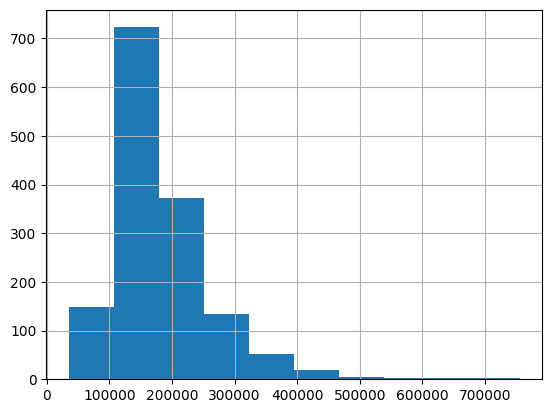

In [5]:
# Histogram - for univariate data
#
# Use case: Getting a rough idea of the distribution of sales price of houses
# described in the dataset
df['SalePrice'].hist()

<Axes: xlabel='Electrical'>

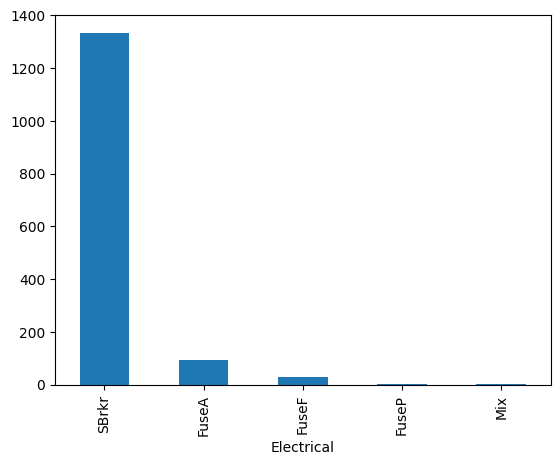

In [6]:
# Bar chart - for univariate data
#
# Scenario: See what electrical system most houses in our dataset have
df['Electrical'].value_counts().plot.bar()

<Axes: >

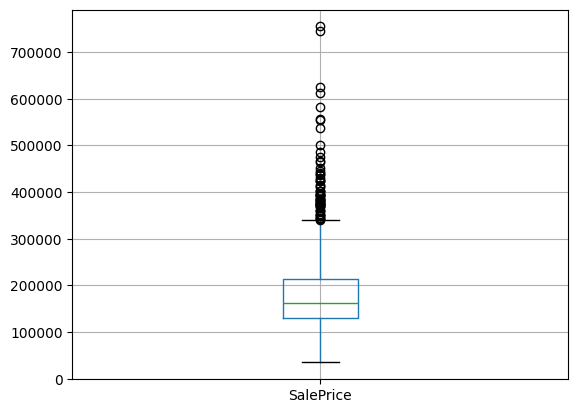

In [7]:
# Quartile plot (or box and whisker plot with outliers)
#
# We'll be visualizing the values of sales price column here
df.boxplot(column="SalePrice")

<Axes: ylabel='Density'>

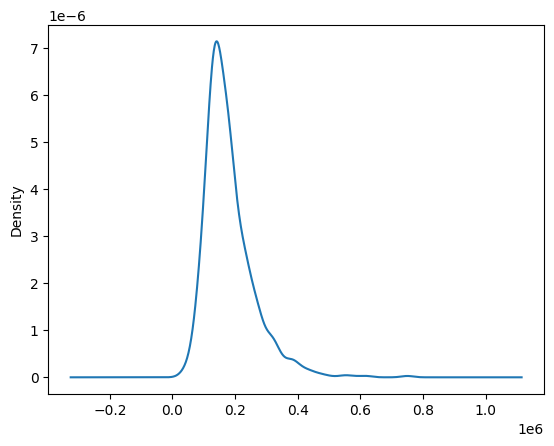

In [8]:
# Distribution chart
#
# We'll be using KDE (kernel density estimation) chart here to visualize the
# distribution of our data here)
df["SalePrice"].plot.kde()

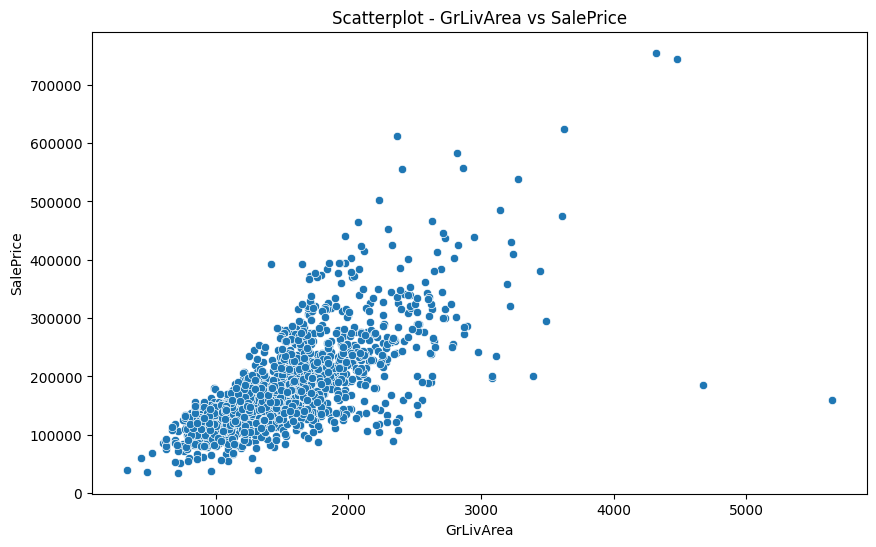

In [ ]:
# Scatterplot for two numerical columns - multivariate data
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('Scatterplot - GrLivArea vs SalePrice')
plt.show()

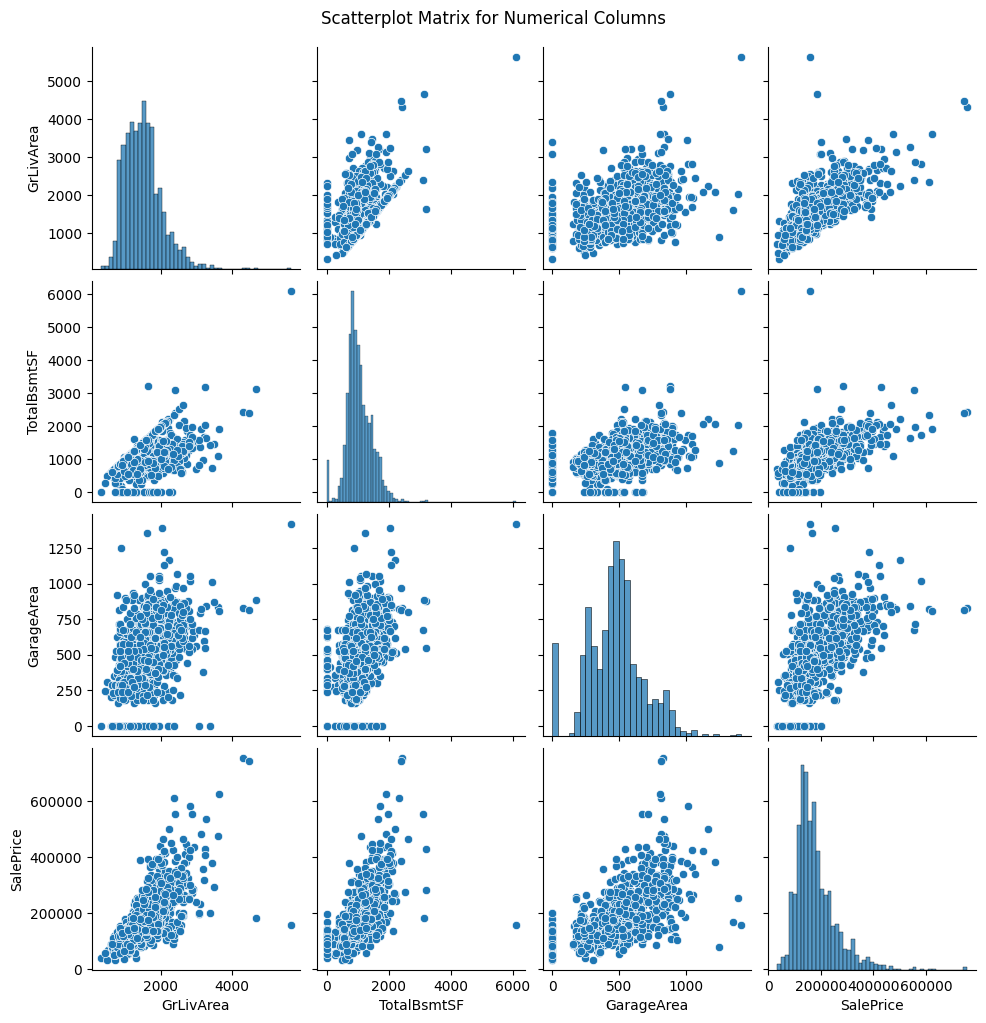

In [ ]:
# Scatterplot Matrix for selected numerical columns
selected_numerical_columns = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'SalePrice']
sns.pairplot(df[selected_numerical_columns])
plt.suptitle('Scatterplot Matrix for Numerical Columns', y=1.02)
plt.show()

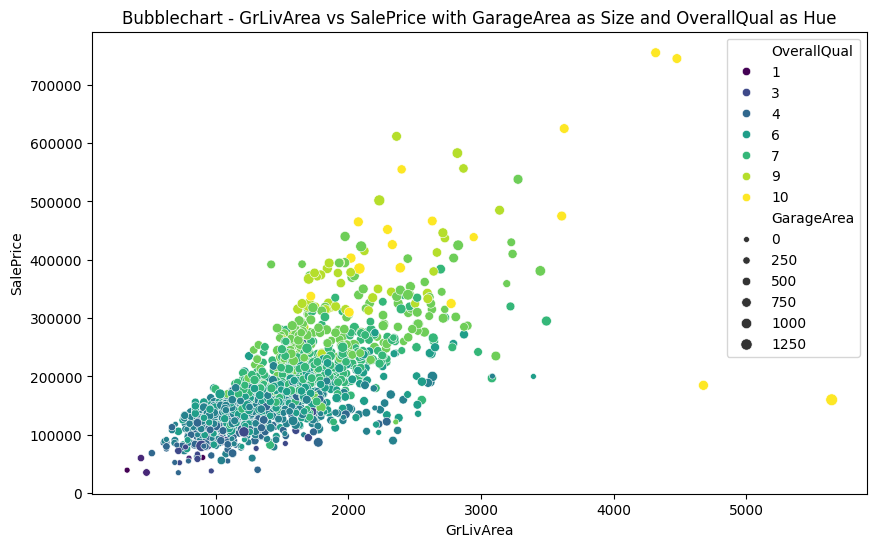

In [ ]:
# Bubblechart for three numerical columns with hue based on a categorical variable
# (Use case: Looking for a plot with with best returns based on given returns in desired price range)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', size='GarageArea', hue='OverallQual', data=df, palette='viridis')
plt.title('Bubblechart - GrLivArea vs SalePrice with GarageArea as Size and OverallQual as Hue')
plt.show()

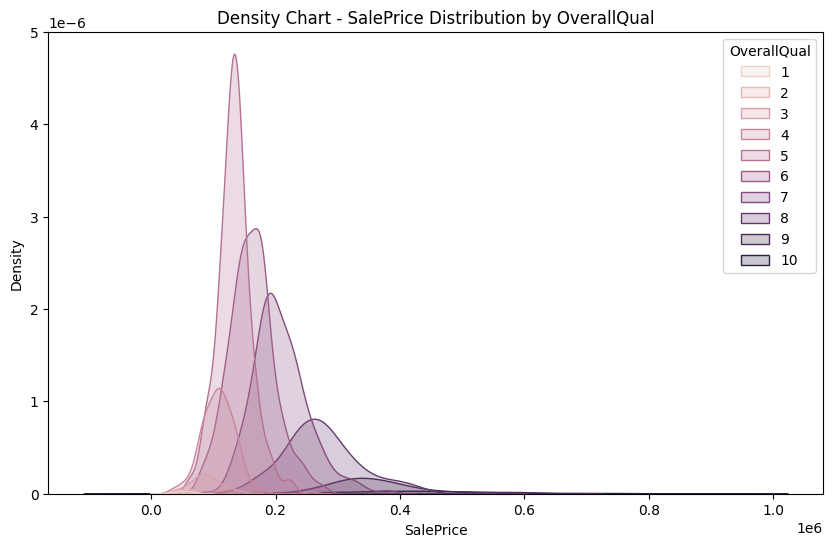

In [ ]:
# Density Chart (KDE) for SalePrice based on OverallQual
plt.figure(figsize=(10, 6))
sns.kdeplot(x='SalePrice', hue='OverallQual', fill=True,  data=df)
plt.title('Density Chart - SalePrice Distribution by OverallQual')
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.show()

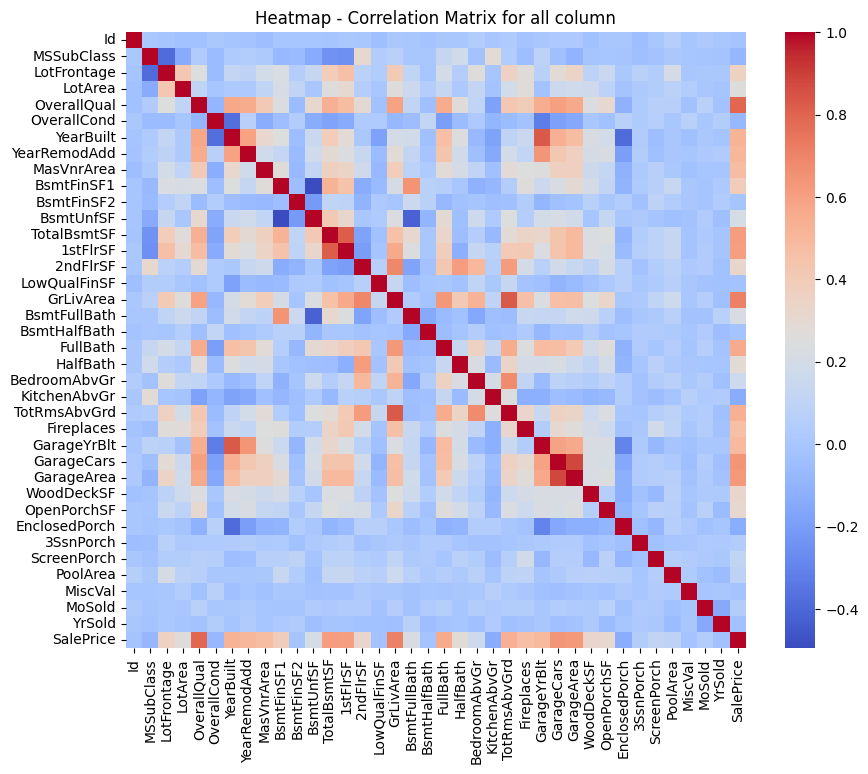

In [ ]:
# Heatmap for correlation matrix of all columns
# (Use case: Can be used to analysis the possible linear relationship that could exist between any two columns)
correlation_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Heatmap - Correlation Matrix for all column')
plt.show()